# IMPORT LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load cleaned data

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f"Shape: {df.shape}")

Shape: (283726, 32)


## 2. Split features and target

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']

print(f"Shape: X {X.shape}, y {y.shape}")

Shape: X (283726, 31), y (283726,)


## 3. Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")

print("\n--- Percent Fraud (%) ---")
print(f"Original: {y.value_counts(normalize=True)[1]*100:.4f}%")
print(f"Train set: {y_train.value_counts(normalize=True)[1]*100:.4f}%")
print(f"Test set: {y_test.value_counts(normalize=True)[1]*100:.4f}%")

X_train shape: (226980, 31) | y_train shape: (226980,)
X_test shape: (56746, 31) | y_test shape: (56746,)

--- Percent Fraud (%) ---
Original: 0.1667%
Train set: 0.1665%
Test set: 0.1674%


## 4. Features Engineering

### Transform amount

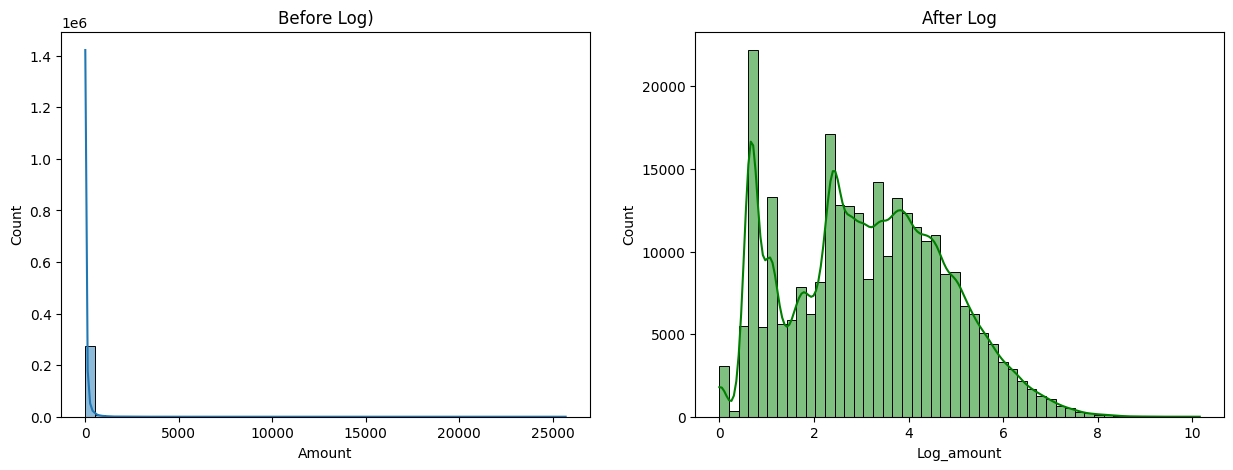

In [5]:
df['Log_amount'] = np.log1p(df['Amount'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Amount'], bins=50, ax=ax1, kde=True)
ax1.set_title('Before Log)')

sns.histplot(df['Log_amount'], bins=50, ax=ax2, kde=True, color='green')
ax2.set_title('After Log')

plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

X_train['Amount'] = np.log1p(X_train['Amount'])
X_test['Amount'] = np.log1p(X_test['Amount'])

scaler = StandardScaler()

X_train[['Amount', 'Hour']] = scaler.fit_transform(X_train[['Amount', 'Hour']])
X_test[['Amount', 'Hour']] = scaler.transform(X_test[['Amount', 'Hour']])

### Why Avoid Fitting Scaler on Test Set? (Data Leakage)

**1. The Concept of Data Leakage:**
Data leakage occurs when information from outside the training dataset is used to create the model. If we `fit` the scaler on the entire dataset or the test set, the **mean** and **standard deviation** of the test data "leaks" into the training process.

**2. Why we only fit on X_train:**
* **Scenario A (Wrong):** Fit on entire data $\rightarrow$ The scaler knows the global distribution. The model performs artificially well on the test set because it was partially prepared using test-set statistics.
* **Scenario B (Right):** Fit on `X_train` only $\rightarrow$ The scaler only knows the training distribution. When we `transform` the `X_test`, we are treating it as **truly unseen data**, simulating how the model will perform in the real world.

**Conclusion:** In a real-world production environment, we won't have the future data (test set) to calculate statistics. Therefore, we must rely solely on our "past knowledge" (training set) to scale any new incoming data.

## 5. Imbalance Handling

In [24]:
# Random Undersampling
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

rus = RandomUnderSampler(random_state = 42, sampling_strategy = 'majority')

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# Counter use for count how many time data appear

print(f"Before undersamping: {Counter(y_train)}")
print(f"After undersampling: {Counter(y_train_under)}")

usp = (Counter(y_train)[0] - Counter(y_train_under)[0]) / Counter(y_train)[0] * 100

print(f"Lost data percent: {round(usp, 2)}%")

Before undersamping: Counter({0: 226602, 1: 378})
After undersampling: Counter({0: 378, 1: 378})
Lost data percent: 99.83%


### Method 1: Random Under-sampling (RUS)

### 1. Concept
**Random Under-sampling** balances the dataset by randomly removing samples from the majority class (**Non-Fraud**) until it matches the minority class (**Fraud**).
---
### 2. Experimental Results
Based on the execution, here are the distribution changes:
| Status | Class 0 (Normal) | Class 1 (Fraud) | Total Samples |
| :--- | :---: | :---: | :---: |
| **Before RUS** | 226,602 | 378 | 226,980 |
| **After RUS** | 378 | 378 | 756 |

> **Critical Warning:** Data Loss Ratio: **99.83%**
---
### 3. Quick Analysis
#### Pros
* **Efficiency:** Extremely fast training due to 99% reduction in data size.
* **Balanced Bias:** Eliminates the model's preference for the majority class.
#### Cons
* **Information Loss:** Discards 226,000+ legitimate transactions, losing vital spending patterns.
* **Underfitting:** 756 samples are insufficient to learn 30 complex features (V1-V28, Amount, Hour).
* **High Variance:** Results depend heavily on which specific 378 "lucky" samples were kept.
---
### Conclusion
This method serves as a **"Proof of Concept"** only. For a production-grade fraud detection model, we need data-preserving techniques like **SMOTE** or **Cost-sensitive Learning**.

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy='minority')

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE: {Counter(y_train_smote)}")


Before SMOTE: Counter({0: 226602, 1: 378})
After SMOTE: Counter({0: 226602, 1: 226602})


### Method 2: SMOTE (Oversampling)
### 1. Concept
**SMOTE** (Synthetic Minority Over-sampling Technique) balances the dataset by creating **synthetic** examples rather than simple duplication. It uses **k-Nearest Neighbors (k-NN)** to interpolate new points between existing minority samples.
---
### 2. Experimental Results
* **Original Fraud Samples:** 378
* **Post-SMOTE Fraud Samples:** ~226,602 (Equal to Majority Class)
* **Data Retention:** 100% of original information is preserved.
---
### 3. Quick Analysis
#### Pros
* **No Information Loss:** Unlike Under-sampling, all legitimate transactions are kept.
* **Better Generalization:** Provides new, synthetic patterns for the model to learn, reducing overfitting compared to random oversampling.
#### Cons
* **Bridge to Noise:** Can create "noisy" samples if fraud points are located deep within the normal class clusters.
* **Training Time:** Increases dataset size significantly, leading to slower training.
---
### Final Verdict
SMOTE is the **Industry Standard** for fraud detection. It forces the model to learn the "area" of fraud rather than just memorizing specific instances.

In [38]:
total_train_original = 226980
class_0_orig = 226602
class_1_orig = 378

data = {
    'Strategy': ['Original (Imbalanced)', 'Undersampling', 'SMOTE (Oversampling)'],
    'Train Size Before': [total_train_original, total_train_original, total_train_original],
    'Train Size After': [total_train_original, class_1_orig * 2, class_0_orig * 2],
    'Class 0 (Normal)': [class_0_orig, class_1_orig, class_0_orig],
    'Class 1 (Fraud)': [class_1_orig, class_1_orig, class_0_orig],
}

df_compare = pd.DataFrame(data)

df_compare['% Data Retained'] = (df_compare['Train Size After'] / df_compare['Train Size Before'] * 100).round(2)

print("--- Comparison of Resampling Strategies (Training Set) ---")
display(df_compare)

--- Comparison of Resampling Strategies (Training Set) ---


,Strategy,Train Size Before,Train Size After,Class 0 (Normal),Class 1 (Fraud),% Data Retained
0,Original (Imbalanced),226980,226980,226602,378,100.00
1,Undersampling,226980,756,378,378,0.33
2,SMOTE (Oversampling),226980,453204,226602,226602,199.67
